In [1]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import cv2  # OpenCV for image processing
import random
from collections import Counter
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# File path for metadata and base directory for audio files
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'
base_dir = r'D:\audio_files\undersampled_audio'
spectrogram_dir = r'D:\audio_spectrograms'

# Create directory for spectrograms if it doesn't exist
os.makedirs(spectrogram_dir, exist_ok=True)

# Step 1: Reading Metadata and Extracting Labels
labels = {}
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Step 2: Generate and Save Mel Spectrograms
spectrogram_data = []
spectrogram_labels = []

def save_mel_spectrogram(file_path, label):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_DB = librosa.power_to_db(S, ref=np.max)
    spectrogram_name = os.path.join(spectrogram_dir, os.path.basename(file_path).replace('.flac', '.png'))
    
    # Save spectrogram as image
    plt.figure(figsize=(4, 4))
    librosa.display.specshow(S_DB, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.axis('off')
    plt.savefig(spectrogram_name, bbox_inches='tight', pad_inches=0)
    plt.close()

    # Load the saved image, resize it, and add to dataset
    img = cv2.imread(spectrogram_name, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (128, 128))
    
    spectrogram_data.append(img_resized)
    spectrogram_labels.append(label)

# Step 3: Match Metadata with Audio Files and Generate Spectrograms
for i in range(4):
    if i == 0:
        flac_dir = os.path.join(base_dir, 'flac')
    else:
        flac_dir = os.path.join(base_dir, f'flac{i}')
    
    flac_files = glob.glob(os.path.join(flac_dir, '*.flac'))
    for flac_file in flac_files:
        file_name = os.path.basename(flac_file)
        file_identifier = file_name.split('.')[0]
        
        if file_identifier in labels:
            save_mel_spectrogram(flac_file, labels[file_identifier])


# Convert to NumPy arrays for training
X = np.array(spectrogram_data).reshape(-1, 128, 128, 1) / 255.0
y = np.array([1 if lbl == 'spoof' else 0 for lbl in spectrogram_labels])
y = to_categorical(y, num_classes=2)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Define and Train the CNN Model
def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create and train the CNN model
model = create_cnn_model()
model.summary()
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [5]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import cv2  # OpenCV for image processing
import random
from collections import Counter
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# File path for metadata and base directory for audio files
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'
base_dir = r'D:\audio_files\undersampled_audio'
spectrogram_dir = r'D:\audio_spectrograms'

# Create directory for spectrograms if it doesn't exist
os.makedirs(spectrogram_dir, exist_ok=True)

# Step 1: Reading Metadata and Extracting Labels
labels = {}
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

print(f"Extracted labels: {len(labels)}")
for key, value in list(labels.items())[:10]:  # Print first 10 for inspection
    print(f"{key}: {value}")

# Step 2: Generate and Save Mel Spectrograms
spectrogram_data = []
spectrogram_labels = []

def save_mel_spectrogram(file_path, label):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_DB = librosa.power_to_db(S, ref=np.max)
    spectrogram_name = os.path.join(spectrogram_dir, os.path.basename(file_path).replace('.flac', '.png'))
    
    # Save spectrogram as image
    plt.figure(figsize=(4, 4))
    librosa.display.specshow(S_DB, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.axis('off')
    plt.savefig(spectrogram_name, bbox_inches='tight', pad_inches=0)
    plt.close()

    # Debugging print statement
    print(f"Saved spectrogram: {spectrogram_name}")

    # Load the saved image, resize it, and add to dataset
    img = cv2.imread(spectrogram_name, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (128, 128))
    
    spectrogram_data.append(img_resized)
    spectrogram_labels.append(label)

# Step 3: Match Metadata with Audio Files and Generate Spectrograms
for i in range(4):
    if i == 0:
        flac_dir = os.path.join(base_dir, 'flac')
    else:
        flac_dir = os.path.join(base_dir, f'flac{i}')
    
    flac_files = glob.glob(os.path.join(flac_dir, '*.flac'))
    print(f"Checking directory: {flac_dir} - Found {len(flac_files)} files")

    for flac_file in flac_files:
        file_name = os.path.basename(flac_file)
        file_identifier = file_name.split('.')[0]
        print(f"Processing file: {file_name} - Identifier: {file_identifier}")
        
        if file_identifier in labels:
            print(f"Label found for {file_identifier}: {labels[file_identifier]}")
            save_mel_spectrogram(flac_file, labels[file_identifier])
        else:
            print(f"No label found for {file_identifier}")

# Debugging statement to check if spectrograms were created
print(f"Total spectrograms generated: {len(spectrogram_data)}")

# Convert to NumPy arrays for training
if len(spectrogram_data) == 0:
    print("No spectrograms were created. Please check the file paths and try again.")
else:
    X = np.array(spectrogram_data).reshape(-1, 128, 128, 1) / 255.0
    y = np.array([1 if lbl == 'spoof' else 0 for lbl in spectrogram_labels])
    y = to_categorical(y, num_classes=2)

    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Step 5: Define and Train the CNN Model
    def create_cnn_model():
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation='relu'),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(128, activation='relu'),
            Dropout(0.5),
            Dense(2, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    # Create and train the CNN model
    model = create_cnn_model()
    model.summary()
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Extracted labels: 611829
DF_E_2000011: spoof
DF_E_2000013: spoof
DF_E_2000024: spoof
DF_E_2000026: spoof
DF_E_2000027: spoof
DF_E_2000028: spoof
DF_E_2000031: spoof
DF_E_2000032: spoof
DF_E_2000040: spoof
DF_E_2000042: spoof
Checking directory: D:\audio_files\undersampled_audio\flac - Found 0 files
Checking directory: D:\audio_files\undersampled_audio\flac1 - Found 0 files
Checking directory: D:\audio_files\undersampled_audio\flac2 - Found 0 files
Checking directory: D:\audio_files\undersampled_audio\flac3 - Found 0 files
Total spectrograms generated: 0
No spectrograms were created. Please check the file paths and try again.


Found 45234 audio files with corresponding labels.


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 314s 270ms/step - accuracy: 0.7676 - loss: 0.5042 - val_accuracy: 0.8403 - val_loss: 0.3426
Epoch 2/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 294s 260ms/step - accuracy: 0.8402 - loss: 0.3431 - val_accuracy: 0.8963 - val_loss: 0.2375
Epoch 3/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 295s 261ms/step - accuracy: 0.8979 - loss: 0.2337 - val_accuracy: 0.9389 - val_loss: 0.1731
Epoch 4/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 294s 260ms/step - accuracy: 0.9300 - loss: 0.1620 - val_accuracy: 0.9577 - val_loss: 0.1217
Epoch 5/5
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 296s 261ms/step - accuracy: 0.9494 - loss: 0.1230 - val_accuracy: 0.9639 - val_loss: 0.1071


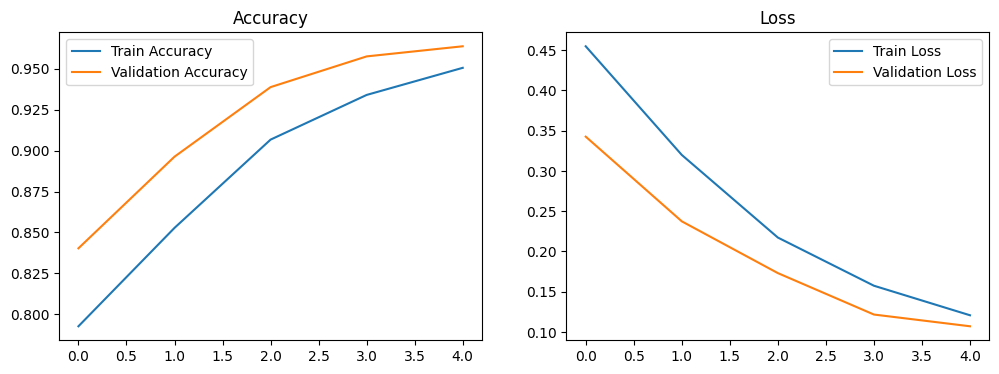

In [6]:
# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

import glob
import os

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

import librosa
import numpy as np
import cv2

def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)

# Split the data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN architecture
def build_cnn(input_shape):
    model = models.Sequential()
    
    # 1st Convolutional Layer
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 2nd Convolutional Layer
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # 3rd Convolutional Layer
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output and add fully connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Output layer (binary classification)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define the input shape for the CNN
input_shape = (128, 128, 1)

# Build the model
model = build_cnn(input_shape)

# Print the model summary
model.summary()

# Define early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Plot accuracy and loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Make predictions on the validation set
y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary labels (0 or 1)

# Print the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

# Optional: Print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Bonafide', 'Spoof']))


283/283 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step
Confusion Matrix:
[[4457   54]
 [ 273 4263]]

Classification Report:
              precision    recall  f1-score   support

    Bonafide       0.94      0.99      0.96      4511
       Spoof       0.99      0.94      0.96      4536

    accuracy                           0.96      9047
   macro avg       0.96      0.96      0.96      9047
weighted avg       0.96      0.96      0.96      9047



In [8]:
model.save('MFCC_model.keras')

In [9]:
from keras.models import load_model

model = load_model('MFCC_model.keras')

loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f'Accuracy: {accuracy:.2f}')




Accuracy: 0.96
